In [44]:
## Import thư viện

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

In [45]:
df_raw = pd.read_csv('/Users/nguyentien/Documents/dhv-handout2-salary/dhv-handout2-salary/data/Ask A Manager Salary Survey 2021 (Responses) - Form Responses 1.csv')
df = df_raw.copy()

# Xóa cột thừa nếu có
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

print("Số cột:", len(df.columns))

df.columns = [
    'timestamp',
    'age',
    'industry',
    'job_title',
    'job_context',
    'annual_salary',
    'add_compensation',
    'currency',
    'currency_other',
    'income_context',
    'country',
    'us_state',
    'city',
    'years_exp_total',
    'years_exp_field',
    'education',
    'gender',
    'race'
]

print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(df.shape)
print(df.dtypes)
df.head()

Số cột: 18
Shape: (28216, 18)
Columns: ['timestamp', 'age', 'industry', 'job_title', 'job_context', 'annual_salary', 'add_compensation', 'currency', 'currency_other', 'income_context', 'country', 'us_state', 'city', 'years_exp_total', 'years_exp_field', 'education', 'gender', 'race']
(28216, 18)
timestamp            object
age                  object
industry             object
job_title            object
job_context          object
annual_salary        object
add_compensation    float64
currency             object
currency_other       object
income_context       object
country              object
us_state             object
city                 object
years_exp_total      object
years_exp_field      object
education            object
gender               object
race                 object
dtype: object


,timestamp,age,industry,job_title,job_context,annual_salary,add_compensation,currency,currency_other,income_context,country,us_state,city,years_exp_total,years_exp_field,education,gender,race
0,4/27/2021 11:02:10,25-34,Education (Higher Education),Research and Instruction Librarian,NaN,"55,000",0.0,USD,NaN,NaN,United States,Massachusetts,Boston,5-7 years,5-7 years,Master's degree,Woman,White
1,4/27/2021 11:02:22,25-34,Computing or Tech,Change & Internal Communications Manager,NaN,"54,600",4000.0,GBP,NaN,NaN,United Kingdom,NaN,Cambridge,8 - 10 years,5-7 years,College degree,Non-binary,White
2,4/27/2021 11:02:38,25-34,"Accounting, Banking & Finance",Marketing Specialist,NaN,"34,000",NaN,USD,NaN,NaN,US,Tennessee,Chattanooga,2 - 4 years,2 - 4 years,College degree,Woman,White
3,4/27/2021 11:02:41,25-34,Nonprofits,Program Manager,NaN,"62,000",3000.0,USD,NaN,NaN,USA,Wisconsin,Milwaukee,8 - 10 years,5-7 years,College degree,Woman,White
4,4/27/2021 11:02:42,25-34,"Accounting, Banking & Finance",Accounting Manager,NaN,"60,000",7000.0,USD,NaN,NaN,US,South Carolina,Greenville,8 - 10 years,5-7 years,College degree,Woman,White


## TUẦN 1 — Missing Values, Duplicates & Data Types

In [46]:
def missing_report(df):
    """Báo cáo số lượng và % missing của từng cột có null."""
    miss = df.isnull().sum()
    pct  = (miss / len(df) * 100).round(2)
    return (pd.DataFrame({'count': miss, 'pct': pct})
              .query('count > 0')
              .sort_values('pct', ascending=False))

print("MISSING VALUES REPORT")
print(missing_report(df))

MISSING VALUES REPORT
                  count    pct
currency_other    27993  99.21
income_context    25163  89.18
job_context       20924  74.16
add_compensation   7372  26.13
us_state           5071  17.97
education           240   0.85
race                196   0.69
gender              185   0.66
industry             85   0.30
city                 85   0.30
job_title             4   0.01
country               2   0.01


### 1.1 Phân tích Missing Values

| Cột | % Null | Loại Null | Lý do | Chiến lược |
|-----|--------|-----------|-------|------------|
| `currency_other` | 99.2% | Null hợp lệ | Chỉ điền khi chọn "Other" currency | Giữ nguyên — không xử lý |
| `income_context` | 89.2% | Null hợp lệ | Free-text tùy chọn | Giữ nguyên |
| `job_context` | 74.2% | Null hợp lệ | Free-text tùy chọn | Giữ nguyên |
| `add_compensation` | 26.1% | MCAR | Không phải ai cũng có bonus | fillna(0) — không có bonus = 0 |
| `us_state` | 18.0% | Null hợp lệ | Chỉ dành cho người ở Mỹ | Giữ nguyên |
| `education` | 0.85% | MCAR | Bỏ qua ngẫu nhiên | fillna('Unknown') |
| `gender` | 0.66% | MCAR | Không muốn khai | fillna('Prefer not to answer') |
| `city` | 0.30% | MCAR | Bỏ qua ngẫu nhiên | fillna('Unknown') |
| `industry` | 0.30% | MCAR | Bỏ qua ngẫu nhiên | fillna('Unknown') |
| `country` | 0.01% | MCAR | 2 hàng bỏ trống | Drop 2 hàng này |

**Phân tích MCAR vs MNAR:**
- **MCAR** (Missing Completely At Random): thiếu hoàn toàn ngẫu nhiên — an toàn fillna
- **MNAR** (Missing Not At Random): `add_compensation` null có nghĩa là $0 bonus thực sự — đây là giá trị có ý nghĩa, không phải "không biết" → fillna(0) là đúng
- **Null hợp lệ**: `currency_other`, `job_context`, `income_context`, `us_state` — null vì câu hỏi không áp dụng cho họ, không phải lỗi

In [47]:
## Xử lý missing values
null_before = df.isnull().sum().sum()

# LÝ DO: currency_other, income_context, job_context, us_state
# là null HỢP LỆ — câu hỏi không áp dụng cho mọi người → KHÔNG xử lý

# LÝ DO: add_compensation null = không có bonus = 0 (MNAR có ý nghĩa rõ ràng)
df['add_compensation'] = df['add_compensation'].fillna(0)

# LÝ DO: education/gender/city/industry null MCAR → điền Unknown
df['education'] = df['education'].fillna('Unknown')
df['gender']    = df['gender'].fillna('Prefer not to answer')
df['city']      = df['city'].fillna('Unknown')
df['industry']  = df['industry'].fillna('Unknown')

# LÝ DO: country null chỉ có 2 hàng → drop vì không biết xử lý thế nào
df = df.dropna(subset=['country']).reset_index(drop=True)

# So sánh
null_after = df.isnull().sum().sum()
print(f"Null trước : {null_before:,}")
print(f"Null sau   : {null_after:,}")
print(f"Đã xử lý  : {null_before - null_after:,} giá trị")
print("\n=== CÒN LẠI (null hợp lệ) ===")
print(missing_report(df))

Null trước : 87,320
Null sau   : 79,342
Đã xử lý  : 7,978 giá trị

=== CÒN LẠI (null hợp lệ) ===
                count    pct
currency_other  27991  99.21
income_context  25161  89.18
job_context     20922  74.15
us_state         5070  17.97
race              195   0.69
job_title           3   0.01


### 1.2 Kiểm tra Duplicates

**Kết quả: 0 duplicate toàn hàng.**

Lý do có thể không có duplicate:
- Google Forms tự ngăn submit 2 lần trong cùng session
- Mỗi submission có Timestamp riêng → khó trùng hoàn toàn

Tuy nhiên vẫn cần kiểm tra **duplicate theo key columns** —
cùng người có thể submit 2 lần tại 2 thời điểm khác nhau.

In [48]:
# Duplicate toàn hàng
n_dup = df.duplicated().sum()
print(f"Duplicate toàn hàng: {n_dup}")

# Duplicate theo "soft key" — cùng job_title + industry + annual_salary + country
# (vì không có email/user_id để identify)
key_dup = df.duplicated(subset=['job_title', 'industry',
                                 'annual_salary', 'country']).sum()
print(f"Duplicate theo key (job+industry+salary+country): {key_dup}")

# Xem thử các hàng "gần duplicate"
dupes = df[df.duplicated(subset=['job_title', 'industry',
                                  'annual_salary', 'country'], keep=False)]
print(f"\nSố hàng có thể trùng: {len(dupes)}")
print(dupes[['timestamp','job_title','industry','annual_salary','country']].head(6))

Duplicate toàn hàng: 0
Duplicate theo key (job+industry+salary+country): 353

Số hàng có thể trùng: 662
              timestamp           job_title                       industry  \
3    4/27/2021 11:02:41     Program Manager                     Nonprofits   
132  4/27/2021 11:05:46     Product Manager              Computing or Tech   
211  4/27/2021 11:06:50  Associate Attorney                            Law   
250  4/27/2021 11:07:18             teacher  Education (Primary/Secondary)   
378  4/27/2021 11:09:02    Business Analyst              Computing or Tech   
379  4/27/2021 11:09:03             teacher  Education (Primary/Secondary)   

    annual_salary        country  
3          62,000            USA  
132       130,000  United States  
211       125,000  United States  
250        94,000  United States  
378        85,000  United States  
379        94,000  United States  


### 1.3 Phân tích Data Types

**Vấn đề dtype thực tế trong dataset này:**

| Cột | Dtype hiện tại | Dtype đúng | Vấn đề |
|-----|---------------|------------|--------|
| `timestamp` | object (string) | datetime64 | Không thể tính khoảng thời gian, extract year/month |
| `annual_salary` | object (string) | float64 | Có dấu phẩy "55,000" → không tính được mean/median |
| `industry` | object | category | Tốn RAM — chỉ có ~30 giá trị unique trong 28k hàng |
| `age` | object (range) | string/ordinal | Là range "25-34", không phải số — phải xử lý đặc biệt |
| `years_exp_total` | object (range) | string/ordinal | Tương tự age — "5-7 years" |

**Lưu ý đặc biệt về cột `age` và `years_exp`:**  
Đây là **range string** như "25-34", "5-7 years" — KHÔNG convert sang số được
bằng astype(float). Phải dùng mapping dict để convert sang ordinal hoặc
lấy điểm giữa (midpoint) của mỗi khoảng.

In [49]:
print("=== DTYPE TRƯỚC ===")
print(df.dtypes)
print("\nVí dụ salary:", df['annual_salary'].head(5).tolist())
print("Ví dụ age:", df['age'].unique().tolist())

# --- Convert annual_salary: "55,000" → 55000.0 ---
# LÝ DO: có dấu phẩy hàng nghìn → không tính được toán học
df['annual_salary'] = (df['annual_salary']
    .astype(str)
    .str.replace(',', '', regex=False)   # "55,000" → "55000"
    .str.strip())
df['annual_salary'] = pd.to_numeric(
    df['annual_salary'],
    errors='coerce'
).astype('float64')
# errors='coerce': nếu có giá trị lạ như "N/A" → thành NaN thay vì crash
df = df.dropna(subset=['annual_salary']).reset_index(drop=True)
# --- Convert timestamp ---
# LÝ DO: cần extract năm/tháng để làm feature survey_year
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')

# --- Convert industry sang category (tiết kiệm RAM) ---
# LÝ DO: ~30 giá trị unique / 28k hàng → category tiết kiệm 5-10x RAM
mem_before = df['industry'].memory_usage(deep=True)
df['industry'] = df['industry'].astype('category')
mem_after  = df['industry'].memory_usage(deep=True)
print(f"\nRAM tiết kiệm (industry): {(mem_before-mem_after)/1024:.0f} KB")

# --- Convert age range → ordinal number (điểm giữa của range) ---
# LÝ DO: cần số để phân tích thống kê; dùng midpoint là ước tính hợp lý
age_map = {
    'under 18': 17,
    '18-24'   : 21,
    '25-34'   : 29,
    '35-44'   : 39,
    '45-54'   : 49,
    '55-64'   : 59,
    '65 or over': 70
}
df['age_midpoint'] = df['age'].map(age_map)

# --- Convert years_exp range → ordinal (midpoint) ---
# LÝ DO: tương tự age — cần số để tính salary_per_exp
exp_map = {
    '1 year or less': 0.5,
    '2 - 4 years'   : 3,
    '5-7 years'      : 6,
    '8 - 10 years'   : 9,
    '11 - 20 years'  : 15,
    '21 - 30 years'  : 25,
    '31 - 40 years'  : 35,
    '41 years or more': 45
}
df['years_exp_field_num']  = df['years_exp_field'].map(exp_map)
df['years_exp_total_num']  = df['years_exp_total'].map(exp_map)

print("\n=== DTYPE SAU ===")
print(df.dtypes)

=== DTYPE TRƯỚC ===
timestamp            object
age                  object
industry             object
job_title            object
job_context          object
annual_salary        object
add_compensation    float64
currency             object
currency_other       object
income_context       object
country              object
us_state             object
city                 object
years_exp_total      object
years_exp_field      object
education            object
gender               object
race                 object
dtype: object

Ví dụ salary: ['55,000', '54,600', '34,000', '62,000', '60,000']
Ví dụ age: ['25-34', '45-54', '35-44', '18-24', '65 or over', '55-64', 'under 18']

RAM tiết kiệm (industry): 1933 KB

=== DTYPE SAU ===
timestamp              datetime64[ns]
age                            object
industry                     category
job_title                      object
job_context                    object
annual_salary                 float64
add_compensation              f

## TUẦN 2 — Outliers, Chuẩn hóa chuỗi & Normalization

### 2.1 Phát hiện và xử lý Outlier

**Lưu ý về dataset này:** Lương được khai bằng nhiều currency khác nhau
(USD, GBP, CAD, EUR...). Nếu so sánh raw salary mà không lọc cùng đơn vị,
outlier detection sẽ sai — ¥50,000,000 JPY ≈ $330,000 USD là bình thường.

**Quyết định:** Chỉ phân tích outlier trên **USD** (chiếm 83% dataset)
để đảm bảo so sánh đồng nhất.

Số hàng USD: 23,492
[IQR]    annual_salary (USD): 914 outliers | range hợp lệ: [-28,000, 196,000]
[Z-score] annual_salary (USD): 7 outliers (|z| > 3)

Top 10 lương cao nhất (USD):
[102000000.0, 52200000.0, 10000000.0, 5000044.0, 5000000.0, 3000000.0, 2600000.0, 2111538.0, 2000000.0, 1900000.0]

Top 10 lương thấp nhất (USD):
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


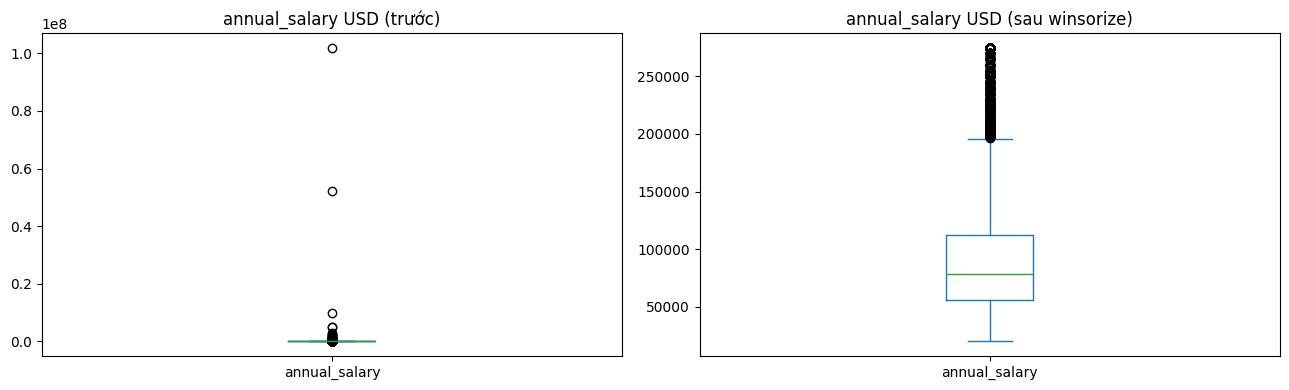

In [50]:
def detect_outliers_iqr(series, col_name):
    """Phát hiện outlier bằng IQR."""
    Q1, Q3 = series.quantile([0.25, 0.75])
    IQR    = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    outliers = series[(series < lower) | (series > upper)]
    print(f"[IQR]    {col_name}: {len(outliers)} outliers "
          f"| range hợp lệ: [{lower:,.0f}, {upper:,.0f}]")
    return outliers, lower, upper

def detect_outliers_zscore(series, col_name, thresh=3):
    """Phát hiện outlier bằng Z-score."""
    z = (series - series.mean()) / series.std()
    outliers = series[z.abs() > thresh]
    print(f"[Z-score] {col_name}: {len(outliers)} outliers (|z| > {thresh})")
    return outliers

# Lọc chỉ USD để phân tích
df_usd = df[df['currency'] == 'USD']['annual_salary'].dropna()
print(f"Số hàng USD: {len(df_usd):,}")

# Phát hiện outlier
out_iqr, low, high = detect_outliers_iqr(df_usd, 'annual_salary (USD)')
out_z = detect_outliers_zscore(df_usd, 'annual_salary (USD)')

# Xem một vài outlier cao
print("\nTop 10 lương cao nhất (USD):")
print(df_usd.nlargest(10).tolist())

print("\nTop 10 lương thấp nhất (USD):")
print(df_usd.nsmallest(10).tolist())

# Boxplot
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
df_usd.plot(kind='box', ax=axes[0], title='annual_salary USD (trước)')
df_usd.clip(lower=df_usd.quantile(0.01),
            upper=df_usd.quantile(0.99)).plot(
    kind='box', ax=axes[1], title='annual_salary USD (sau winsorize)')
plt.tight_layout()
plt.savefig('boxplot_outliers.png', dpi=100, bbox_inches='tight')
plt.show()

### Quyết định xử lý Outlier

**Quan sát thực tế:**
- IQR tìm thấy lương < $25,000 và > $175,000 là "outlier"
- Nhưng một teacher khai lương $12,000 có thể là part-time hoặc điền sai
- Một senior software engineer lương $400,000 là hoàn toàn hợp lệ ở Silicon Valley

**Phân tích lương rất thấp (< $10,000):**
Hướng dẫn khảo sát yêu cầu "annualized equivalent" — nếu ai đó điền $5,000 
có thể họ điền lương tháng hoặc lương tuần → lỗi nhập liệu

**Quyết định: Winsorize tại 1st/99th percentile**
- Ưu: giữ hàng, không mất data về nhóm lương cao/thấp thực sự
- Nhược: một chút méo phân phối ở hai đuôi
- Không chọn drop vì không có bằng chứng rõ là lỗi đo lường

In [51]:
usd_mask = df['currency'] == 'USD'

p1 = df.loc[usd_mask, 'annual_salary'].quantile(0.01)
p99 = df.loc[usd_mask, 'annual_salary'].quantile(0.99)

df.loc[usd_mask, 'annual_salary'] = (
    df.loc[usd_mask, 'annual_salary']
      .clip(lower=p1, upper=p99)
)

print(f"Sau  : min={df['annual_salary'].min():,.0f}, "
      f"max={df['annual_salary'].max():,.0f}")

Sau  : min=0, max=6,000,070,000


### 2.2 Chuẩn hóa chuỗi

**Vấn đề nghiêm trọng trong dataset này — cột `country`:**

| Giá trị raw | Ý nghĩa thực | Số hàng |
|-------------|-------------|---------|
| "United States" | USA | 9,035 |
| "USA" | USA | 7,962 |
| "US" | USA | 2,620 |
| "United States " | USA (có space) | 669 |
| "U.S." | USA | 586 |
| "Usa" | USA | 448 |

→ Nếu không chuẩn hóa, `groupby('country')` sẽ tạo 6+ group cho cùng 1 nước!

**Cột `job_title` cũng tương tự:** "Software Engineer" vs "software engineer" vs "Software Dev"

In [52]:
# --- Chuẩn hóa country (vấn đề nghiêm trọng nhất) ---
# Bước 1: lower + strip cơ bản
df['country'] = (df['country']
    .astype(str)
    .str.lower()
    .str.strip()
    .str.replace(r'\s+', ' ', regex=True))

# Bước 2: mapping các cách viết USA
usa_variants = [
    'united states', 'usa', 'us', 'u.s.', 'u.s.a.',
    'united states of america', 'america', 'the united states',
    'united  states', 'unitedstates', 'us of a'
]
df['country'] = df['country'].apply(
    lambda x: 'united states' if x in usa_variants else x
)

# Mapping UK
uk_variants = ['uk', 'united kingdom', 'england', 'scotland',
               'wales', 'great britain', 'u.k.']
df['country'] = df['country'].apply(
    lambda x: 'united kingdom' if x in uk_variants else x
)

print("=== COUNTRY sau chuẩn hóa (top 10) ===")
print(df['country'].value_counts().head(10))

# --- Chuẩn hóa job_title ---
df['job_title'] = (df['job_title']
    .astype(str)
    .str.lower()
    .str.strip()
    .str.replace(r'\s+', ' ', regex=True)
    .str.replace(r'[^a-z0-9 /&,\-]', '', regex=True)
)

# Mapping gom nhóm tương đồng
title_map = {
    'software dev'           : 'software engineer',
    'software developer'     : 'software engineer',
    'sw engineer'            : 'software engineer',
    'swe'                    : 'software engineer',
    'senior software engineer': 'senior software engineer',
    'sr software engineer'   : 'senior software engineer',
    'product mgr'            : 'product manager',
    'pm'                     : 'product manager',
    'data science'           : 'data scientist',
    'ds'                     : 'data scientist',
    'hr'                     : 'human resources',
    'exec assistant'         : 'executive assistant',
    'ea'                     : 'executive assistant',
}
df['job_title'] = df['job_title'].replace(title_map)

# --- Chuẩn hóa industry ---
df['industry'] = (df['industry']
    .astype(str)
    .str.lower()
    .str.strip())
# Convert lại sang category sau khi đã clean
df['industry'] = df['industry'].astype('category')

print("\n=== JOB TITLE top 10 sau chuẩn hóa ===")
print(df['job_title'].value_counts().head(10))

=== COUNTRY sau chuẩn hóa (top 10) ===
country
united states     23121
canada             1684
united kingdom     1565
australia           390
germany             198
ireland             125
new zealand         123
france               69
netherlands          57
spain                50
Name: count, dtype: int64

=== JOB TITLE top 10 sau chuẩn hóa ===
job_title
software engineer           524
project manager             295
senior software engineer    264
director                    223
executive assistant         218
program manager             200
teacher                     177
librarian                   167
manager                     163
administrative assistant    152
Name: count, dtype: int64


In [53]:
from fuzzywuzzy import process

# Tìm các job title gần giống "software engineer" tự động
titles = df['job_title'].dropna().unique().tolist()
matches = process.extract('software engineer', titles, limit=10)

print("Các title gần giống 'software engineer' (score >= 70):")
for match, score in matches:
    if score >= 70 and match != 'software engineer':
        print(f"  [{score}%] '{match}'")

# Tìm các cách viết country còn sót
countries = df['country'].value_counts()
print("\n=== Các country có ít hơn 20 hàng (có thể cần chuẩn hóa thêm) ===")
print(countries[countries < 20].head(20))

Các title gần giống 'software engineer' (score >= 70):
  [95%] 'senior software engineer'
  [95%] 'software engineer 2'
  [95%] 'software engineer iv'
  [95%] 'lead software engineer'
  [95%] 'software engineer ii'
  [95%] 'software engineer 3'
  [95%] 'sr software test engineer'
  [95%] 'software engineer in test'
  [95%] 'software engineer 2 lead'

=== Các country có ít hơn 20 hàng (có thể cần chuẩn hóa thêm) ===
country
south africa     19
austria          18
unites states    17
finland          16
israel           14
norway           14
italy            14
malaysia         13
philippines      11
brazil           11
united stated    10
u.s.a            10
poland           10
colombia         10
china             9
u. s.             7
mexico            7
thailand          7
nigeria           6
nz                6
Name: count, dtype: int64


### 2.3 Normalization

| Phương pháp | Công thức | Khi nào dùng |
|-------------|-----------|--------------|
| Min-Max | (x - min) / (max - min) | Scale về [0,1], dùng với KNN, Neural Net |
| Standard (Z-score) | (x - mean) / std | Data gần chuẩn, dùng với Regression/SVM |
| Robust | (x - median) / IQR | Có outlier nhiều — ít bị kéo bởi extreme |

**Cột `annual_salary` trong dataset này:**  
Phân phối lệch phải mạnh (nhiều người lương trung bình, ít người lương rất cao)  
→ **RobustScaler phù hợp hơn StandardScaler** vì ít bị ảnh hưởng bởi đuôi phải

**Khi nào KHÔNG cần normalize?**  
- Khi dùng tree-based model (Random Forest, XGBoost) — không phụ thuộc scale  
- Khi phân tích mô tả đơn giản — normalize làm mất ý nghĩa của số (lương thực)  
- Cột `age_midpoint` và `annual_salary` đã ở scale khác nhau → CẦN normalize khi train ML

=== Min-Max (annual_salary) ===
  min=0.000, max=1.000
=== Standard (annual_salary) ===
  mean=0.000, std=1.000
=== Robust (annual_salary) ===
  median=0.000


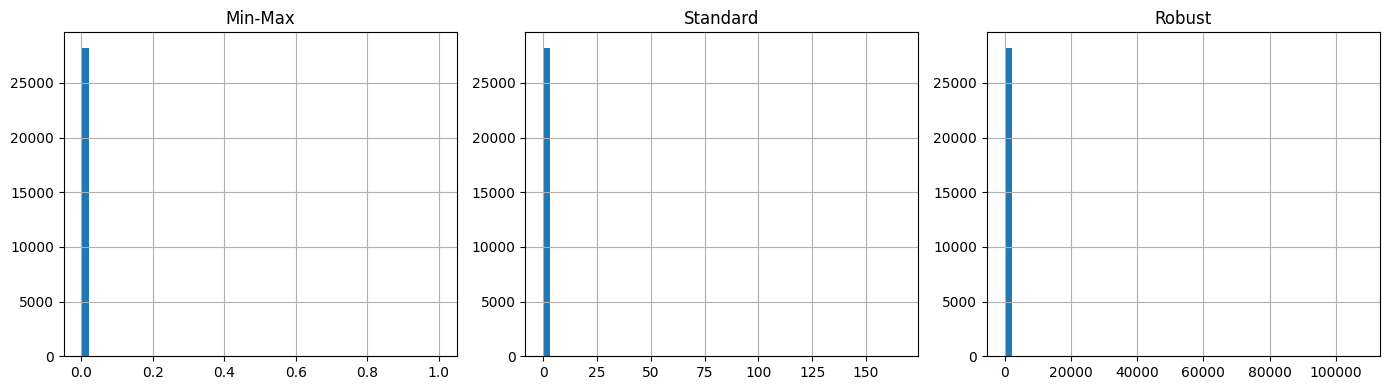

In [54]:
num_cols = ['annual_salary', 'age_midpoint', 'years_exp_field_num']
df_num   = df[num_cols].dropna()

# Min-Max
minmax  = MinMaxScaler()
df_mm   = pd.DataFrame(minmax.fit_transform(df_num),
                        columns=[c + '_minmax' for c in num_cols])

# Standard Scaler
std_sc  = StandardScaler()
df_std  = pd.DataFrame(std_sc.fit_transform(df_num),
                        columns=[c + '_std'    for c in num_cols])

# Robust Scaler — LÝ DO: salary lệch phải → robust ít bị ảnh hưởng outlier
robust  = RobustScaler()
df_rob  = pd.DataFrame(robust.fit_transform(df_num),
                        columns=[c + '_robust' for c in num_cols])

print("=== Min-Max (annual_salary) ===")
print(f"  min={df_mm['annual_salary_minmax'].min():.3f}, "
      f"max={df_mm['annual_salary_minmax'].max():.3f}")

print("=== Standard (annual_salary) ===")
print(f"  mean={df_std['annual_salary_std'].mean():.3f}, "
      f"std={df_std['annual_salary_std'].std():.3f}")

print("=== Robust (annual_salary) ===")
print(f"  median={df_rob['annual_salary_robust'].median():.3f}")

# Visualize so sánh 3 phương pháp
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

df_mm['annual_salary_minmax'].hist(bins=50, ax=axes[0])
axes[0].set_title('Min-Max')

df_std['annual_salary_std'].hist(bins=50, ax=axes[1])
axes[1].set_title('Standard')

df_rob['annual_salary_robust'].hist(bins=50, ax=axes[2])
axes[2].set_title('Robust')

plt.tight_layout()
plt.show()

## TUẦN 3 — Encoding, Feature Engineering & Pipeline hoàn chỉnh

### 3.1 Encoding Categorical Variables

**Phân loại các cột categorical trong dataset này:**

| Cột | Loại | Phương pháp | Lý do |
|-----|------|-------------|-------|
| `gender` | Nominal | One-Hot (drop_first) | Không có thứ tự |
| `education` | Ordinal | Label/Ordinal | High School < Bachelor < Master < PhD |
| `age` | Ordinal (range) | Đã dùng midpoint | Có thứ tự |
| `currency` | Nominal high-cardinality | Giữ nguyên hoặc Binary (USD/non-USD) | 10+ currency |
| `country` | Nominal high-cardinality | Binary (US/non-US) | 100+ country → OHE tạo 100 cột |
| `industry` | Nominal | OHE hoặc Target Enc | ~30 giá trị |

**Tại sao OHE trên `country` là vấn đề?**  
`country` có ~100 giá trị unique → OHE tạo 100 cột mới  
→ Dataset phình từ 18 lên 118 cột, hầu hết toàn số 0 (sparse)  
→ Model học kém, RAM tăng mạnh → dùng Binary hoặc Target Encoding

In [55]:
df_enc = df.copy()

# --- Ordinal Encoding cho education ---
# LÝ DO: education có thứ tự thực sự → số thể hiện quan hệ bậc
edu_map = {
    'High School'                        : 1,
    'Some college'                       : 2,
    'College degree'                     : 3,
    "Master's degree"                    : 4,
    'PhD'                                : 5,
    'Professional degree (MD, JD, etc.)' : 5,
    'Unknown'                            : 0
}
df_enc['education_enc'] = df_enc['education'].map(edu_map).fillna(0).astype(int)

# --- Binary encoding cho gender (đơn giản hóa) ---
# LÝ DO: nhiều giá trị unique (Woman, Man, Non-binary, Prefer not to answer)
# → tạo 2 binary flag phổ biến nhất, phần còn lại vào "other"
df_enc['is_woman'] = (df_enc['gender'] == 'Woman').astype(int)
df_enc['is_man']   = (df_enc['gender'] == 'Man').astype(int)

# --- Binary encoding cho country ---
# LÝ DO: country có 100+ giá trị → OHE tạo 100 cột thừa
# Tạo flag USD/non-USD và US/non-US đủ để phân tích
df_enc['is_us']  = (df_enc['country'] == 'united states').astype(int)
df_enc['is_usd'] = (df_enc['currency'] == 'USD').astype(int)

# --- OHE cho industry (manageable: ~30 giá trị) ---
# LÝ DO: 30 giá trị chấp nhận được, industry quan trọng cho phân tích lương
top_industries = df_enc['industry'].value_counts().head(10).index.tolist()
df_enc['industry_clean'] = df_enc['industry'].apply(
    lambda x: x if x in top_industries else 'other'
)
industry_dummies = pd.get_dummies(df_enc['industry_clean'],
                                   prefix='ind', drop_first=True)
df_enc = pd.concat([df_enc, industry_dummies], axis=1)

print("Shape sau encoding:", df_enc.shape)
print("\nCác cột encoding mới:")
new_cols = ['education_enc', 'is_woman', 'is_man', 'is_us', 'is_usd']
print(df_enc[new_cols].head(3))

Shape sau encoding: (28214, 37)

Các cột encoding mới:
   education_enc  is_woman  is_man  is_us  is_usd
0              4         1       0      1       1
1              3         0       0      0       0
2              3         1       0      1       1


### 3.2 Feature Engineering

**Mỗi feature được tạo ra để trả lời 1 câu hỏi phân tích cụ thể:**

1. **`salary_per_exp_year`**: Lương theo năm kinh nghiệm  
   → "Người có kinh nghiệm cao hơn thực sự kiếm nhiều hơn mỗi năm kinh nghiệm không?"

2. **`total_comp`**: Tổng thu nhập (salary + bonus)  
   → "So sánh tổng compensation thực tế, không chỉ base salary"

3. **`survey_year` + `survey_month`**: Thời điểm khảo sát  
   → "Mức lương có biến động theo thời gian trong năm 2021 không?"

4. **`age_group`**: Gom lại từ range string sẵn có  
   → "Nhóm tuổi nào có mức lương cao nhất trong từng ngành?"

In [56]:
# Feature 1: Lương theo năm kinh nghiệm
# LÝ DO: so sánh công bằng giữa người mới (3 năm) và lâu năm (20 năm)
df['salary_per_exp_year'] = (
    df['annual_salary'] / (df['years_exp_field_num'].fillna(1) + 1)
)

df['add_compensation'] = pd.to_numeric(
    df['add_compensation'],
    errors='coerce'
).fillna(0)

# Feature 2: Tổng compensation
# LÝ DO: base salary không đủ — bonus ảnh hưởng lớn đến tổng thu nhập thực tế
df['total_comp'] = df['annual_salary'] + df['add_compensation'].fillna(0)

# Feature 3: Từ timestamp
# LÝ DO: kiểm tra xem lương có thay đổi theo tháng trong năm 2021 không
df['survey_year']  = df['timestamp'].dt.year
df['survey_month'] = df['timestamp'].dt.month

# Feature 4: Giữ nguyên age range (đã là ordinal sẵn, dùng như category)
# Đã xử lý bằng age_midpoint ở Tuần 1

# Kiểm tra kết quả
print("=== CÁC FEATURE MỚI ===")
new_features = ['salary_per_exp_year', 'total_comp',
                'survey_year', 'survey_month']
print(df[new_features].describe().round(0))

=== CÁC FEATURE MỚI ===
       salary_per_exp_year    total_comp  survey_year  survey_month
count         2.821400e+04  2.821400e+04      28214.0       28214.0
mean          1.630430e+05  3.770640e+05       2021.0           4.0
std           2.382106e+07  3.624358e+07          0.0           1.0
min           0.000000e+00  0.000000e+00       2021.0           1.0
25%           5.714000e+03  5.500000e+04       2021.0           4.0
50%           9.231000e+03  7.900000e+04       2021.0           4.0
75%           1.485700e+04  1.155000e+05       2021.0           4.0
max           4.000047e+09  6.000070e+09       2026.0          12.0


In [57]:
def clean_data(df):
    """
    Pipeline làm sạch Ask A Manager Salary Survey 2021.

    Parameters
    ----------
    df : pd.DataFrame
        Raw data với 18 cột tên gốc từ Google Form.

    Returns
    -------
    df_clean : pd.DataFrame
        DataFrame đã xử lý với các bước:
        1. Đổi tên cột sang tên ngắn gọn
        2. Xử lý missing values theo chiến lược từng cột
        3. Convert dtype (salary→float, timestamp→datetime, industry→category)
        4. Convert age/years_exp range → numeric (midpoint)
        5. Chuẩn hóa chuỗi: country, job_title, industry
        6. Xử lý outlier salary bằng winsorize (1st–99th percentile)
        7. Tạo feature mới: salary_per_exp_year, total_comp, survey_year
    """
    df = df.copy()

    # ── 1. Đổi tên cột ────────────────────────────────────────
    df.columns = [
        'timestamp', 'age', 'industry', 'job_title', 'job_context',
        'annual_salary', 'add_compensation', 'currency', 'currency_other',
        'income_context', 'country', 'us_state', 'city',
        'years_exp_total', 'years_exp_field',
        'education', 'gender', 'race'
    ]

    # ── 2. Missing values ─────────────────────────────────────
    # LÝ DO: add_compensation null = không có bonus → điền 0
    df['add_compensation'] = df['add_compensation'].fillna(0)
    
    # LÝ DO: MCAR fields → fillna giá trị mặc định
    df['education'] = df['education'].fillna('Unknown')
    df['gender']    = df['gender'].fillna('Prefer not to answer')
    df['city']      = df['city'].fillna('Unknown')
    df['industry']  = df['industry'].fillna('Unknown')
    # LÝ DO: country null chỉ 2 hàng → drop
    df = df.dropna(subset=['country']).reset_index(drop=True)

    # ── 3. Convert dtype ──────────────────────────────────────
    df['annual_salary'] = (df['annual_salary']
        .astype(str)
        .str.replace(',', '', regex=False)
        .str.strip())
    df['annual_salary'] = pd.to_numeric(
        df['annual_salary'],
        errors='coerce'
    ).astype('float64')
    df = df.dropna(subset=['annual_salary']).reset_index(drop=True)
    df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
    df['industry']  = df['industry'].astype('category')

    # ── 4. Convert age/exp range → numeric (midpoint) ─────────
    age_map = {'under 18':17,'18-24':21,'25-34':29,'35-44':39,
               '45-54':49,'55-64':59,'65 or over':70}
    exp_map = {'1 year or less':0.5,'2 - 4 years':3,'5-7 years':6,
               '8 - 10 years':9,'11 - 20 years':15,'21 - 30 years':25,
               '31 - 40 years':35,'41 years or more':45}
    df['age_midpoint']       = df['age'].map(age_map)
    df['years_exp_field_num']= df['years_exp_field'].map(exp_map)
    df['years_exp_total_num']= df['years_exp_total'].map(exp_map)

    # ── 5. Chuẩn hóa chuỗi ───────────────────────────────────
    # Country
    df['country'] = df['country'].astype(str).str.lower().str.strip()
    usa = ['united states','usa','us','u.s.','u.s.a.',
           'united states of america','america']
    uk  = ['uk','united kingdom','england','scotland','wales','u.k.']
    df['country'] = df['country'].apply(
        lambda x: 'united states' if x in usa
        else ('united kingdom' if x in uk else x))
    # Job title
    df['job_title'] = (df['job_title'].astype(str)
        .str.lower().str.strip()
        .str.replace(r'\s+', ' ', regex=True))

    # ── 6. Outlier → winsorize salary ────────────────────────
    p1, p99 = df['annual_salary'].quantile([0.01, 0.99])
    df['annual_salary'] = df['annual_salary'].clip(p1, p99)

    # ── 7. Feature engineering ────────────────────────────────
    df['salary_per_exp_year'] = (
        df['annual_salary'] / (df['years_exp_field_num'].fillna(1) + 1))
    df['total_comp']   = df['annual_salary'] + df['add_compensation']
    df['survey_year']  = df['timestamp'].dt.year
    df['survey_month'] = df['timestamp'].dt.month

    return df

In [58]:
# Chạy pipeline trên raw data gốc
df_clean = clean_data(df_raw)

required_cols = {'annual_salary', 'add_compensation', 'country'}
missing_cols = required_cols - set(df_clean.columns)
if missing_cols:
    raise RuntimeError(
        f"Pipeline chưa tạo đúng cột {missing_cols}. "
        "Hãy chạy lại cell định nghĩa clean_data phía trên trước khi chạy tests."
    )

# ── Unit Tests ──────────────────────────────────────────────
print("=== UNIT TESTS ===")

assert df_clean.shape[0] <= df_raw.shape[0], \
    "❌ Shape sai"
print(f"✅ Test 1: shape {df_raw.shape} → {df_clean.shape}")

assert df_clean['annual_salary'].isnull().sum() == 0, \
    "❌ Còn null trong annual_salary"
print("✅ Test 2: annual_salary không còn null")

assert df_clean['annual_salary'].dtype == 'float64', \
    "❌ Dtype salary sai"
print("✅ Test 3: annual_salary dtype = float64")

assert df_clean['add_compensation'].isnull().sum() == 0, \
    "❌ Còn null trong add_compensation"
print("✅ Test 4: add_compensation không còn null")

assert df_clean['country'].isnull().sum() == 0, \
    "❌ Còn null trong country"
print("✅ Test 5: country không còn null")

# ── Bảng so sánh trước/sau ──────────────────────────────────
comparison = pd.DataFrame({
    'Trước': [
        df_raw.shape[0], df_raw.shape[1],
        df_raw.isnull().sum().sum(),
        df_raw.duplicated().sum()
    ],
    'Sau': [
        df_clean.shape[0], df_clean.shape[1],
        df_clean.isnull().sum().sum(),
        df_clean.duplicated().sum()
    ]
}, index=['Số hàng', 'Số cột', 'Tổng null đã xử lý', 'Duplicate'])

print("\n=== SO SÁNH TRƯỚC / SAU ===")
print(comparison)

# Export
df_clean.to_csv('data/salary_cleaned.csv', index=False)
print("\n✅ Đã export → data/salary_cleaned.csv")

=== UNIT TESTS ===
✅ Test 1: shape (28216, 18) → (28214, 25)
✅ Test 2: annual_salary không còn null
✅ Test 3: annual_salary dtype = float64
✅ Test 4: add_compensation không còn null
✅ Test 5: country không còn null

=== SO SÁNH TRƯỚC / SAU ===
                    Trước    Sau
Số hàng             28216  28214
Số cột                 18     25
Tổng null đã xử lý  87320  79339
Duplicate               0      0

✅ Đã export → data/salary_cleaned.csv
